# 01d · Separación BCG/ICL usando la API de TNG-Illustris

**Objetivo:** replicar el análisis de `01b_` (perfil de Holmberg, f_ICL) descargando las partículas directamente desde la API web de TNG en vez de leer los archivos de snapshot locales.

---

## ⚠ Diferencia crucial: cutout de subhalo vs cutout de halo FoF

La URL que conoces carga el **subhalo central** (BCG puro, solo partículas ligadas a él):
```python
url = ".../snapshots/99/subhalos/0/cutout.hdf5"
# Equivale a: il.snapshot.loadSubhalo(..., sub_id=0, 'stars')
# → Igual que 01_ (NO igual que 01b_)
```

Para replicar `01b_` (FoF completo sin satélites) necesitamos el **cutout del halo FoF**:
```python
url = ".../snapshots/99/halos/0/cutout.hdf5"
# Equivale a: il.snapshot.loadHalo(..., halo_id=0, 'stars')
# → Todas las estrellas del FoF, incluyendo satélites → luego aplicamos máscara
```

Este notebook usa el cutout de halo FoF + la misma máscara de `01b_` para ser consistente.

---

**Parámetro principal a cambiar:**
```python
GROUP_IDX = 0   # posición en el catálogo ICL local
```

In [39]:
import sys, os, pickle, time
import numpy as np
import h5py
import requests
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.stats import binned_statistic_2d
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, './original_shift_code')
import illustris_python as il
import Catalogue
import params_icl as P

FIG_PDF = './figuras/01d_api_tng_BCG_ICL/pdf'
FIG_PNG = './figuras/01d_api_tng_BCG_ICL/png'
os.makedirs(FIG_PDF, exist_ok=True)
os.makedirs(FIG_PNG, exist_ok=True)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110,
                     'font.size': 12,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089)
h=0.6774

## Configuración — API key y grupo a analizar

In [2]:
# ── Parámetros principales ──────────────────────────────────────────────
API_KEY   = "4fc61d9b3796c16ec02f0299703478ef"   # ← tu clave de https://www.tng-project.org/users/profile/
GROUP_IDX = 0                   # ← posición en el catálogo ICL local (0-based)
# ────────────────────────────────────────────────────────────────────────

BASE_URL = "https://www.tng-project.org/api/TNG100-1"
SNAP     = P.SNAP   # 99

# Carpeta local donde se guarda el cutout descargado
CUTOUT_DIR = './tng_data'
os.makedirs(CUTOUT_DIR, exist_ok=True)

## Funciones de la API

In [3]:
def api_get(url, params=None):
    """
    GET a la API de TNG. Devuelve JSON si el Content-Type es JSON,
    o el objeto Response completo si es binario (para cutouts HDF5).
    """
    headers = {"api-key": API_KEY}
    r = requests.get(url, headers=headers, params=params, stream=True)
    r.raise_for_status()
    if 'application/json' in r.headers.get('Content-Type', ''):
        return r.json()
    return r


def download_cutout(url, params, local_path, overwrite=False):
    """
    Descarga un cutout HDF5 de la API y lo guarda en local_path.
    Si ya existe y overwrite=False, lo reutiliza (evita descargas repetidas).

    Retorna la ruta del archivo guardado.
    """
    if os.path.exists(local_path) and not overwrite:
        print(f"  Reutilizando cutout local: {local_path}")
        return local_path

    print(f"  Descargando: {url}")
    r = api_get(url, params=params)

    with open(local_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            f.write(chunk)

    size_mb = os.path.getsize(local_path) / 1e6
    print(f"  Guardado ({size_mb:.1f} MB): {local_path}")
    return local_path


# Test rápido de conexión
try:
    resp = api_get(f"{BASE_URL}/")
    print(f"Conexión OK — simulación: {resp.get('name', '?')}")
    print(f"  Snapshots disponibles: {resp.get('num_snapshots', '?')}")
except Exception as e:
    print(f"[ERROR] No se pudo conectar a la API: {e}")
    print("  Revisa tu API_KEY y tu conexión a internet.")

Conexión OK — simulación: TNG100-1
  Snapshots disponibles: 100


## Cargar catálogo local y obtener FOF_IDX

In [4]:
with h5py.File(P.CATALOG_OUT, 'r') as f:
    group_idx_cat = f['group_idx'][:]
    M200c_all     = f['M200c_Msun'][:]
    R200c_all     = f['R200c_kpc'][:]
    GroupPos_all  = f['GroupPos_kpc'][:]
    bcg_sub_all   = f['bcg_sub_idx'][:]
    t_last_all    = f['t_last_merger_Gyr'][:]
    icl_frac_sub  = f['icl_frac'][:] if 'icl_frac' in f else None

FOF_IDX  = int(group_idx_cat[GROUP_IDX])
M200c    = M200c_all[GROUP_IDX]
R200c    = R200c_all[GROUP_IDX]
GroupPos = GroupPos_all[GROUP_IDX]
BCG_sub  = int(bcg_sub_all[GROUP_IDX])

print(f"Grupo seleccionado (GROUP_IDX={GROUP_IDX}):")
print(f"  FOF_IDX TNG    : {FOF_IDX}")
print(f"  BCG subfind ID : {BCG_sub}")
print(f"  log M200c      : {np.log10(M200c):.2f} M_sun")
print(f"  R200c          : {R200c:.1f} kpc")

Grupo seleccionado (GROUP_IDX=0):
  FOF_IDX TNG    : 0
  BCG subfind ID : 0
  log M200c      : 14.58 M_sun
  R200c          : 1523.0 kpc


## Cargar metadatos del halo desde archivos locales

`GroupFirstSub`, `GroupNsubs` y `SubhaloLenType` **no están disponibles de forma fiable en la respuesta JSON de la API** — como se pudo comprobar arriba, `Group_M_Crit200` devuelve `?` y el loop original causaba `NameError`.

Los cargamos directamente desde los archivos locales con `illustris_python`, igual que en `01b_`.  
La API solo se usará para lo que realmente requiere conexión: descargar el cutout de partículas.

In [5]:
# ── GroupFirstSub, GroupNsubs y BoxSize desde archivos locales ──────────
halo_fields = il.groupcat.loadHalos(P.basePath, P.SNAP,
                                     fields=['GroupFirstSub', 'GroupNsubs'])
first_sub = int(halo_fields['GroupFirstSub'][FOF_IDX])
n_subs    = int(halo_fields['GroupNsubs'][FOF_IDX])

header  = il.groupcat.loadHeader(P.basePath, P.SNAP)
box_kpc = header['BoxSize'] * P.UL   # ckpc/h → kpc físicos

print(f"Halo FoF {FOF_IDX} (cargado localmente):")
print(f"  GroupFirstSub : {first_sub}")
print(f"  GroupNsubs    : {n_subs}")
print(f"  BoxSize       : {box_kpc:.1f} kpc")

# ── SubhaloLenType: una sola carga global + slicing ─────────────────────
# Más rápido que N llamadas a la API — y sin rate-limit
all_lens = il.groupcat.loadSubhalos(P.basePath, P.SNAP,
                                     fields=['SubhaloLenType'])
if all_lens.ndim == 1:
    all_lens = all_lens.reshape(-1, 6)

lens_star = all_lens[first_sub : first_sub + n_subs, 4].astype(int)

print(f"\nSubhaloLenType[4] (estrellas) cargado localmente:")
print(f"  Total en subhalos : {lens_star.sum():,}")
print(f"  Central (sub 0)   : {lens_star[0]:,}")
print(f"  Satélites (1..N-1): {lens_star[1:].sum():,}")

Halo FoF 0 (cargado localmente):
  GroupFirstSub : 0
  GroupNsubs    : 17185
  BoxSize       : 110717.4 kpc

SubhaloLenType[4] (estrellas) cargado localmente:
  Total en subhalos : 11,810,749
  Central (sub 0)   : 3,987,343
  Satélites (1..N-1): 7,823,406


## Descargar cutout del halo FoF

Descargamos **el cutout del halo FoF completo** (equivalente a `loadHalo` en local).  
Se guarda en disco para no repetir la descarga en ejecuciones posteriores.

> **Nota:** La API también ofrece `/subhalos/{id}/cutout.hdf5` que descarga solo las partículas  
> ligadas a ese subhalo (equivalente a `loadSubhalo`). Eso sería equivalente a `01_`, **no a `01b_`**.

In [37]:
# funcion para normalizar distancias

def Distance_1D(X, X_POS, BoxSize):
    '''This function takes as input a 1D vector containing the positions of particles, the X_POS(float) that is the position respect to where we will compute the Distance and the BoxSize, this function consider a periodical Box. The output is a 1D vector with the same size than X containing the distance from X to X_POS'''
    D=X-X_POS
    D=np.where(D>BoxSize/2, D-BoxSize, D)
    D=np.where(D<-BoxSize/2, D+BoxSize, D)
    return D 

In [43]:
cutout_fields = 'Coordinates,Masses,GFM_StellarPhotometrics'

# URL del cutout del halo FoF completo
cutout_url   = f"{BASE_URL}/snapshots/{SNAP}/halos/{FOF_IDX}/cutout.hdf5"
cutout_local = f"{CUTOUT_DIR}/cutout_halo_{FOF_IDX}_snap{SNAP}.hdf5"

cutout_path = download_cutout(
    cutout_url,
    params={'stars': cutout_fields},
    local_path=cutout_local,
    overwrite=False   # ← True para forzar re-descarga
)

# Leer el archivo HDF5 descargado
with h5py.File(cutout_path, 'r') as f:
    keys = list(f['PartType4'].keys())
    pos_raw_ckpc = f['PartType4']['Coordinates'][:]          # ckpc/h
    mass_raw     = f['PartType4']['Masses'][:]               # 1e10 M_sun/h
    phot_raw     = f['PartType4']['GFM_StellarPhotometrics'][:]  # mag AB

# Convertir unidades (idéntico a 01b_)
pos_raw = Distance_1D(pos_raw_ckpc, 0, 75000) * P.UL    # kpc físicos
mass    = mass_raw    * P.UM     # M_sun

if phot_raw.ndim == 1:
    phot_raw = phot_raw.reshape(-1, 8)

n_fof_total = len(mass)
print(f"\nPartículas estelares en el cutout FoF: {n_fof_total:,}")
print(f"Campos disponibles en PartType4: {keys}")

  Reutilizando cutout local: ./tng_data/cutout_halo_0_snap99.hdf5

Partículas estelares en el cutout FoF: 11,816,696
Campos disponibles en PartType4: ['Coordinates', 'GFM_StellarPhotometrics', 'Masses']


In [44]:
phot_raw[:, 4]

array([-8.800264, -8.69202 , -8.352194, ...,  0.      ,  0.      ,
        0.      ], dtype=float32)

In [46]:
# test de visualizacion

# plt.hist2d(pos_raw[:, 0], pos_raw[:, 1], weights=phot_raw[:, 4], bins=[150,150])

## Construir máscara de satélites — idéntica a `01b_`

Las partículas en el cutout del FoF están ordenadas exactamente igual que en los archivos locales:  
`[subhalo 0] [subhalo 1] ... [subhalo N-1] [no ligadas]`  
Usamos `lens_star` (obtenido de la API arriba) para construir la máscara.

In [ ]:
def mask_from_lens(lens_star, n_total_fof, exclude_satellites=True):
    """
    Máscara booleana: True = subhalo 0 (central) + partículas no ligadas.
    False = subhalos satélites 1..N-1.
    Función idéntica a la de 01b_.
    """
    if not exclude_satellites:
        return np.ones(n_total_fof, dtype=bool)
    mask = np.zeros(n_total_fof, dtype=bool)
    n_central = int(lens_star[0]) if len(lens_star) > 0 else n_total_fof
    mask[:n_central] = True
    total_in_subhalos = int(lens_star.sum())
    if total_in_subhalos < n_total_fof:
        mask[total_in_subhalos:] = True
    return mask


mask = mask_from_lens(lens_star, n_fof_total, exclude_satellites=True)

n_central   = int(lens_star[0])
n_sat       = int(lens_star[1:].sum())
n_unbound   = mask.sum() - n_central

print(f"Desglose de partículas (cutout API):")
print(f"  Total FoF         : {n_fof_total:>8,}")
print(f"  Subhalo central   : {n_central:>8,}  (conservadas)")
print(f"  Satélites (excl.) : {n_sat:>8,}  (excluidas)")
print(f"  No ligadas        : {n_unbound:>8,}  (conservadas — ICL difusa)")
print(f"  Usadas para perfil: {mask.sum():>8,}")

# Aplicar máscara
pos_sel  = pos_raw[mask]
mass_sel = mass[mask]
phot_sel = phot_raw[mask]
# índice 1 = B-band (Johnson, Vega) en GFM_StellarPhotometrics (U,B,V,K,g,r,i,z)
lum_b    = 10**((P.M_SUN_B_VEGA - phot_sel[:, 1]) / 2.5)

## Funciones auxiliares — idénticas a `01b_`

In [ ]:
def rotate_by_inertia_tensor(pos_rel, mass, r_lim=np.inf):
    dist = np.linalg.norm(pos_rel, axis=1)
    ok   = (dist > 0) & (dist <= r_lim) & np.isfinite(mass)
    p, m = pos_rel[ok], mass[ok]
    if m.sum() == 0 or len(m) < 4:
        return pos_rel, np.eye(3)
    w    = 1.0 / dist[ok]**2
    mtot = np.sum(m)
    Ixx  = np.sum(m * p[:,0]**2 * w) / mtot
    Iyy  = np.sum(m * p[:,1]**2 * w) / mtot
    Izz  = np.sum(m * p[:,2]**2 * w) / mtot
    Ixy  = np.sum(m * p[:,0] * p[:,1] * w) / mtot
    Ixz  = np.sum(m * p[:,0] * p[:,2] * w) / mtot
    Iyz  = np.sum(m * p[:,1] * p[:,2] * w) / mtot
    I    = np.array([[Ixx, Ixy, Ixz],
                     [Ixy, Iyy, Iyz],
                     [Ixz, Iyz, Izz]])
    eigvals, eigvecs = np.linalg.eigh(I)
    idx    = np.argsort(eigvals)[::-1]
    R_mat  = eigvecs[:, idx].T
    return pos_rel @ R_mat.T, R_mat


def sb_profile_b(r_2d, lum_b, r_max_kpc, n_bins=60):
    """Perfil 1D de brillo superficial en banda B (Johnson, Vega)."""
    r_bins = np.logspace(np.log10(0.5), np.log10(r_max_kpc), n_bins + 1)
    r_mid  = np.sqrt(r_bins[:-1] * r_bins[1:])
    mu_b   = np.full(n_bins, np.nan)
    for k, (r1, r2) in enumerate(zip(r_bins[:-1], r_bins[1:])):
        mk = (r_2d >= r1) & (r_2d < r2)
        if mk.sum() == 0:
            continue
        area_pc2 = np.pi * ((r2 * 1e3)**2 - (r1 * 1e3)**2)
        sigma_L  = lum_b[mk].sum() / area_pc2
        if sigma_L > 0:
            mu_b[k] = P.SB_CONST - 2.5 * np.log10(sigma_L)
    return r_mid, mu_b


def holmberg_radius(r_mid, mu_b, mu_cut=P.MU_HOLMBERG):
    valid = np.isfinite(mu_b) & (r_mid > 0)
    if valid.sum() < 3:
        return np.nan
    r_v, m_v = r_mid[valid], mu_b[valid]
    idx_s    = np.argsort(r_v)
    r_v, m_v = r_v[idx_s], m_v[idx_s]
    if m_v[0] > mu_cut or m_v[-1] < mu_cut:
        return np.nan
    try:
        f   = interp1d(m_v, r_v, kind='linear', fill_value='extrapolate')
        r_h = float(f(mu_cut))
        return r_h if 0 < r_h <= r_v[-1] * 1.2 else np.nan
    except Exception:
        return np.nan

## Análisis: perfil de Holmberg y separación BCG/ICL

A partir de aquí el análisis es **idéntico a `01b_`** — solo cambia la fuente de los datos (API vs archivos locales).

In [ ]:
# box_kpc ya está cargado desde il.groupcat.loadHeader en la celda anterior

# Centrar en el BCG y corregir periodicidad
pos_c = Catalogue.Distance_3D(pos_sel, GroupPos, box_kpc)

# Rotar al plano del eje mayor
pos_rot, R_mat = rotate_by_inertia_tensor(pos_c, mass_sel)
r_2d = np.sqrt(pos_rot[:, 0]**2 + pos_rot[:, 1]**2)

# Perfil de brillo superficial
r_max       = np.percentile(r_2d, 99)
r_mid, mu_b = sb_profile_b(r_2d, lum_b, r_max)

# Radio de Holmberg
r_h = holmberg_radius(r_mid, mu_b)

# Separación BCG/ICL
mask_bcg = r_2d <= r_h
mask_icl = r_2d >  r_h
M_bcg    = mass_sel[mask_bcg].sum()
M_icl    = mass_sel[mask_icl].sum()
f_icl    = M_icl / (M_bcg + M_icl)

print(f"Radio de Holmberg : {r_h:.1f} kpc")
print(f"M_BCG             : {M_bcg:.3e} M_sun  (log = {np.log10(M_bcg):.2f})")
print(f"M_ICL             : {M_icl:.3e} M_sun  (log = {np.log10(M_icl):.2f})")
print(f"f_ICL (API / FoF) : {f_icl:.4f}")

# Comparar con 01b_ si está guardado en el catálogo
try:
    with h5py.File(P.CATALOG_OUT, 'r') as f:
        if 'icl_frac_fof' in f:
            f_icl_01b = f['icl_frac_fof'][GROUP_IDX]
            print(f"\nComparación con 01b_ (mismo grupo):")
            print(f"  f_ICL_FoF (01b_) : {f_icl_01b:.4f}")
            print(f"  f_ICL_FoF (API)  : {f_icl:.4f}")
            print(f"  Δ                : {abs(f_icl - f_icl_01b):.4f}")
            print("  (deberían ser idénticos si el cutout API = loadHalo local)")
except Exception:
    pass

### Figura 1 – Perfil de brillo superficial 1D

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
valid = np.isfinite(mu_b)

ax.plot(r_mid[valid], mu_b[valid], 'k-', lw=2,
        label='BCG+ICL (cutout API, FoF sin satélites)')
ax.axhline(P.MU_HOLMBERG, color='r', ls='--', lw=1.5,
           label=f'μ_B = {P.MU_HOLMBERG} mag/arcsec²')
if np.isfinite(r_h):
    ax.axvline(r_h, color='r', ls=':', lw=1.5,
               label=f'R_Holmberg = {r_h:.0f} kpc')
    ax.fill_betweenx([mu_b[valid].min()-1, P.MU_HOLMBERG+4],
                      0, r_h, alpha=0.10, color='royalblue', label='BCG')
    ax.fill_betweenx([mu_b[valid].min()-1, P.MU_HOLMBERG+4],
                      r_h, r_mid[valid][-1], alpha=0.10, color='tomato', label='ICL')
ax.axvline(R200c, color='gray', ls='-.', lw=1.2,
           label=f'R₂₀₀c = {R200c:.0f} kpc')
ax.invert_yaxis()
ax.set_xlabel('Radio semi-mayor [kpc]')
ax.set_ylabel(r'$\mu_B$ [mag arcsec$^{-2}$]')
ax.set_title(f'Perfil SB — FoF {FOF_IDX}  (cutout API, snap {SNAP})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01d_perfil_sb_fof{FOF_IDX}_snap{SNAP}.pdf', bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01d_perfil_sb_fof{FOF_IDX}_snap{SNAP}.png', bbox_inches='tight', dpi=150)
plt.show()

### Figura 2 – Mapa 2D de brillo superficial

In [ ]:
r_plot  = R200c
n_pix   = 216
edges   = np.linspace(-r_plot, r_plot, n_pix + 1)
pix_pc2 = ((2 * r_plot / n_pix) * 1e3)**2

H, _, _, _ = binned_statistic_2d(pos_rot[:, 0], pos_rot[:, 1],
                                   lum_b, statistic='sum',
                                   bins=[edges, edges])
with np.errstate(divide='ignore', invalid='ignore'):
    sigma  = np.where(H > 0, H / pix_pc2, np.nan)
    mu_map = np.where(sigma > 0, P.SB_CONST - 2.5 * np.log10(sigma), np.nan)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mu_map.T, origin='lower', cmap='ocean',
               extent=[-r_plot, r_plot, -r_plot, r_plot],
               vmin=20, vmax=30)
plt.colorbar(im, ax=ax, label=r'$\mu_B$ [mag arcsec$^{-2}$]')
if np.isfinite(r_h):
    ax.add_patch(plt.Circle((0, 0), r_h, fill=False, color='black',
                              lw=1.5, label=f'R$_H$={r_h:.0f} kpc', alpha=0.7))
ax.add_patch(plt.Circle((0, 0), R200c, fill=False, color='gray',
                          lw=1, ls='--', label='R₂₀₀c'))
ax.set_xlabel('x [kpc]'); ax.set_ylabel('y [kpc]')
ax.set_title(f'Mapa 2D SB — FoF {FOF_IDX}  (cutout API)')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01d_mapa_sb_fof{FOF_IDX}_snap{SNAP}.pdf', bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01d_mapa_sb_fof{FOF_IDX}_snap{SNAP}.png', bbox_inches='tight', dpi=150)
plt.show()

### Figura 3 – f_ICL (API) vs f_ICL (01b_ local)

Compara los resultados de los dos métodos de acceso a los datos para verificar que son equivalentes.

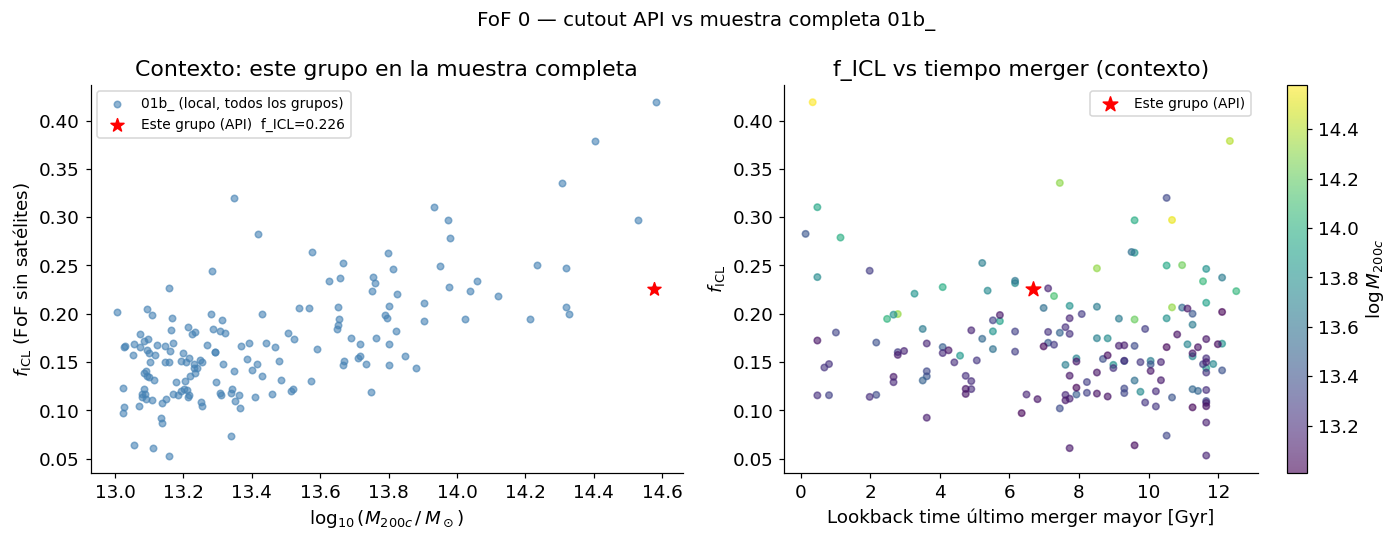

In [12]:
try:
    with h5py.File(P.CATALOG_OUT, 'r') as f:
        icl_frac_fof = f['icl_frac_fof'][:] if 'icl_frac_fof' in f else None
        M200c_all_   = f['M200c_Msun'][:]
        t_merger     = f['t_last_merger_Gyr'][:]
except Exception:
    icl_frac_fof = None

if icl_frac_fof is not None:
    lM = np.log10(M200c_all_)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Panel izq: f_ICL de 01b_ para toda la muestra, marcando el grupo de la API
    ax = axes[0]
    ax.scatter(lM, icl_frac_fof, color='steelblue', s=18, alpha=0.6,
               label='01b_ (local, todos los grupos)')
    ax.scatter(np.log10(M200c), f_icl, color='red', s=80, zorder=5,
               label=f'Este grupo (API)  f_ICL={f_icl:.3f}', marker='*')
    ax.set_xlabel(r'$\log_{10}(M_{200c}\,/\,M_\odot)$')
    ax.set_ylabel(r'$f_{\rm ICL}$ (FoF sin satélites)')
    ax.set_title('Contexto: este grupo en la muestra completa')
    ax.legend(fontsize=9)

    # Panel der: f_ICL (API) vs tiempo desde último merger
    ax = axes[1]
    valid = np.isfinite(t_merger) & np.isfinite(icl_frac_fof)
    sc = ax.scatter(t_merger[valid], icl_frac_fof[valid],
                    c=lM[valid], cmap='viridis', s=18, alpha=0.6)
    plt.colorbar(sc, ax=ax, label=r'$\log M_{200c}$')
    # Marcar el grupo de este notebook
    t_this = t_merger[GROUP_IDX]
    if np.isfinite(t_this):
        ax.scatter(t_this, f_icl, color='red', s=100, zorder=5,
                   marker='*', label='Este grupo (API)')
        ax.legend(fontsize=9)
    ax.set_xlabel('Lookback time último merger mayor [Gyr]')
    ax.set_ylabel(r'$f_{\rm ICL}$')
    ax.set_title('f_ICL vs tiempo merger (contexto)')

    plt.suptitle(f'FoF {FOF_IDX} — cutout API vs muestra completa 01b_', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{FIG_PDF}/fig01d_contexto_fof{FOF_IDX}.pdf', bbox_inches='tight')
    plt.savefig(f'{FIG_PNG}/fig01d_contexto_fof{FOF_IDX}.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("No se encontró icl_frac_fof en el catálogo. Corre primero 01b_.")